# Fitting probability distributions

Fitting probability distributions to data is an important task in any discipline of science and engineering, as these distributions can be used to derive quantitative statements about risks and frequencies of uncertain properties. In this workshop, you will first work with a dataset of your choosing to estimate a distribution, and evaluate the quality of your fit. Then, you will build and analyze a contingency table that describes the relationship between two variables.

**The goal of this project is:**
1. Choose a reasonable distribution function for your chosen dataset, analyzing the statistics of the observations.
2. Fit the chosen distribution by moments.
3. Assess the fit computing probabilities analytically.
4. Assess the fit using goodness-of-fit techniques and computer code.
5. Build a contingency table from two variables and reason about their dependence.

The workshop is divided into 4 parts: 1) data analysis, 2) pen-and-paper practice, 3) programming, and 4) contingency tables.

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
from scipy import stats

plt.rcParams.update({'font.size': 14})


**Please choose one of the following datasets:**

1. Observations of the **compressive strength of concrete**. The compressive strength of concrete is key for the safety of infrastructures and buildings. However, a lot of boundary conditions influence the final resistance of the concrete, such as the cement content, the environmental temperature, or the age of the concrete.
2. ERA5 predictions of the **hourly temperature at 2m height** during the summer months (June, July, August) from 2005 to 2025. ERA5 predictions are re-analysis data, which are observation-corrected weather model predictions.

In [84]:
import os
from urllib.request import urlretrieve

def findfile(fname):
    if not os.path.isfile(fname):
        print(f'Downloading {fname}...')
        urlretrieve('https://github.com/TUDelft-MUDE/source-files/raw/main/file/'+fname, fname)

findfile('dataset_concrete.csv')
findfile('dataset_temperature.csv')


In [85]:
# Please choose one of the datasets below
viable_datasets = ['concrete', 'temperature']
dataset = 'concrete'  # Choose one dataset from the list above

assert dataset in viable_datasets, 'Dataset must be in {}.'.format(str(viable_datasets))

data = np.genfromtxt('dataset_{}.csv'.format(dataset), skip_header=1)

if dataset == 'concrete':
    label = 'Concrete compressive strength [MPa]'
    number_bins = 10
elif dataset == 'temperature':
    label = 'Summer air temperature in Delft [°C]'
    number_bins = 20


Now, let us clean and plot the data.

(-1.6815630164000002, 86.6125956484)

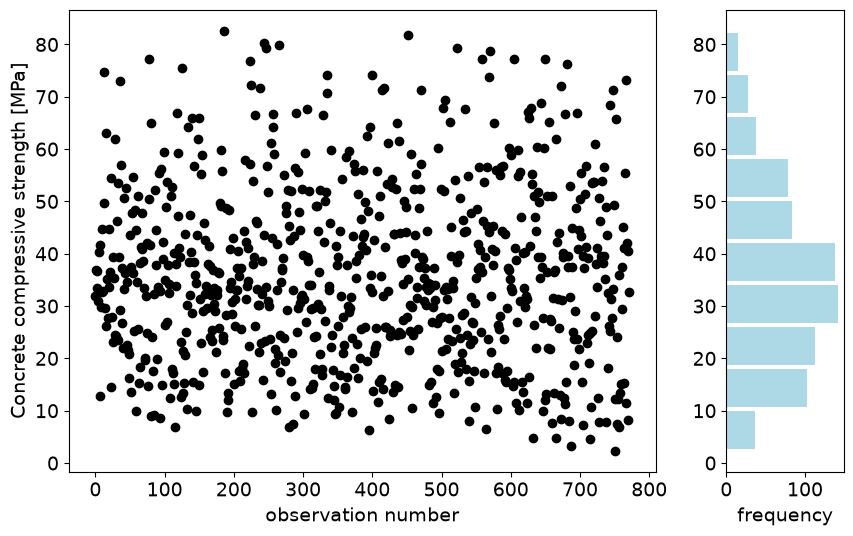

In [86]:
data = data[~np.isnan(data)]

plt.figure(figsize=(10, 6))
gs = GridSpec(nrows=1, ncols=2, width_ratios=[1, 0.2])

plt.subplot(gs[0, 0])
plt.plot(data, 'ok')
plt.xlabel('observation number'); plt.ylabel(label)
ylims = plt.gca().get_ylim()

plt.subplot(gs[0, 1])
plt.hist(data, orientation='horizontal', color='lightblue', rwidth=0.9, bins=number_bins)
plt.xlabel('frequency'); plt.gca().set_ylim(ylims)


In the figure above, you can see all the observations of your chosen dataset. There is no clear pattern in the observations. Let's see how the statistics look!

In [87]:
df_describe = pd.DataFrame(data)
df_describe.describe()

,0
count,772.000000
mean,35.724196
std,16.797389
min,2.331808
25%,23.677591
50%,33.870853
75%,46.232813
max,82.599225


>**Task 1.1**
>
>Using **ONLY** the statistics calculated above:
>- Choose an appropriate distribution to model the data between the following: (1) Gumbel, (2) Uniform, and (3) Gaussian.
>- Justify your choice.
>
>

The Gumbel distribution is used to model maximum and minimum values, which is the case here, since these values are not close to each other. So this distribution is possible.
The uniform distribution cannot be used, since there is no constant value over the interval.
The Gaussian distribution is not used, because there is some assymetrics in the statistics, so the Gumbel distribution will fit better. 

d_min_50 = 33.87 - 2.33 = 31.54
d_max_50 = 82.60 - 33.87 = 48.72

d_min_50 < d_max_50 the Gumbel distribution is right-tailed

## Part 2: Use pen and paper!

Once you have selected the appropriate distribution, fit it by moments manually and check the fit by computing some probabilities analytically. Remember that you have all the information you need in the textbook. Do not use any computer code for this section — you have to do it with pen and paper. You can use the notebook as a calculator.

>**Task 2.1:**
>
>Fit the selected distribution by moments.


In [103]:
mean = data.mean()
var = data.std()

beta = np.sqrt((6*(var**2)/((np.pi)**2)))
mu = mean - 0.577*beta
print(beta, mu)

13.08838491318853 28.17219814488556


In [104]:
def prob(x):
    result = np.exp(-np.exp(-(x - mu)/beta))
    return result

#for x = 3
print(f'The probability for a compressive strength of x = 3 is {prob(3):.2f}')
#for x = 30
print(f'The probability for a compressive strength of x = 30 is {prob(30):.2f}')
#for x = 75
print(f'The probability for a compressive strength of x = 75 is {prob(75):.2f}')

The probability for a compressive strength of x = 3 is 0.00
The probability for a compressive strength of x = 30 is 0.42
The probability for a compressive strength of x = 75 is 0.97


We can now check the fit by computing manually some probabilities from the fitted distribution and comparing them with the empirical ones.

>**Task 2.2:**
>
>Check the fit of the distribution:
>- Use the min, 25%, 50%, 75%, and max values. What are the non-exceedance probabilities (from the empirical distribution) that correspond to those values?
>- Compute the values of the random variable corresponding to those probabilities using the fitted distribution.
>- Compare the obtained values with the empirical ones and assess the fit.
>
>**Tip:** to compute the predicted minimum and maximum, use the non-exceedance probability of the first and last rank sample in an empirical CDF ($1/(n+1)$ and $n/(n+1)$).
>


In [105]:
n = len(data)
p_min = 1 / (n + 1)
p_max = n / (n + 1)

p = [p_min, 0.25, 0.5, 0.75, p_max]
print(p)

statics = df_describe.describe()

empirical = [statics.iloc[3].iloc[0], statics.iloc[4].iloc[0], statics.iloc[5].iloc[0], statics.iloc[6].iloc[0], statics.iloc[7].iloc[0]]
print(empirical)

predicted = []
for i in p:
    formula_x = mu - (beta*(np.log(-np.log(i))))
    predicted.append(formula_x)

print(predicted)



[0.00129366106080207, 0.25, 0.5, 0.75, 0.9987063389391979]
[np.float64(2.331807832), np.float64(23.6775908075), np.float64(33.87085324), np.float64(46.232813179999994), np.float64(82.5992248)]
[np.float64(3.3741742821605634), np.float64(23.897083224455326), np.float64(32.96926032511528), np.float64(44.479008056647174), np.float64(115.20513957903843)]


*Your answer here — fill in the table below.*

|  | Minimum | P25% | P50% | P75% | Maximum |
|---|---:|---:|---:|---:|---:|
| Non-exceedance prob. | 0.00129 | 0.25 | 0.50 | 0.75 | 0.999 |
| Empirical | 2.33|23.68 | 33.87| 46.23|82.60 |
| Predicted | 3.37|23.90 | 32.97|44.48| 115.2|

## Part 3: Let's do it with Python!

Now, let's assess performance with further goodness-of-fit techniques and see whether they are consistent with the analysis done by hand. Note that you have the pseudo-code for the empirical CDF in the reader.

>**Task 3.1:**
>
>Prepare a function to compute the empirical cumulative distribution function.
>


In [110]:
def ecdf(observations):
    """Return [non_exceedance_probabilities, sorted_values]."""
    sorted_values = np.sort(observations)
    n = sorted_values.size
    non_exceedance_probabilities = np.arange(1, n + 1) / (n + 1)
    return [non_exceedance_probabilities, sorted_values]


>**Task 3.2:**
>
>Transform the parameters of the selected distribution you fitted by moments to loc-scale-shape.
>
>**Hint:** the distributions are listed in the online textbook, but check that the book's formulation matches the Python package's (see the Scipy.stats documentation).


*Your answer here.*

>**Task 3.3:**
>
>Assess the goodness of fit of the distribution you fitted by moments by:
>- Visually comparing the empirical and fitted PDF.
>- Using the exceedance plot in log-scale.
>- Using the QQplot.
>- Interpreting them — do you reach a conclusion similar to Part 2?
>


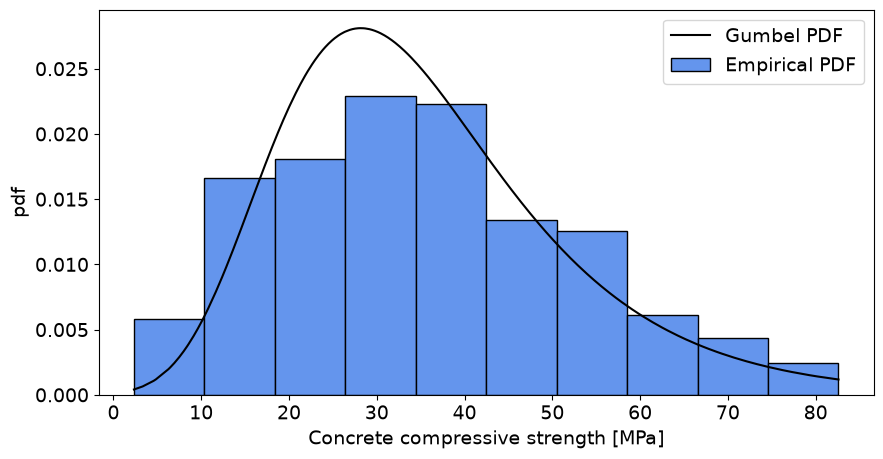

In [123]:
# Visually compare the PDFs
import numpy as np
from scipy.stats import gumbel_r
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import scipy as stats

#Transform to loc, scale
loc = mu
scale = beta 

#Define a vector and evaluate the PDF using both the self-made function and scipy
distribution = gumbel_r.pdf(np.sort(data), loc, scale)

#Compare by plotting
fig, ax = plt.subplots(1,1, figsize=(10, 5))
ax.plot(np.sort(data), distribution, 'k', label = 'Gumbel PDF')
ax.hist(data, edgecolor='k', color='cornflowerblue', label = 'Empirical PDF', density = True)
ax.legend()
ax.set_xlabel('Concrete compressive strength [MPa]')
ax.set_ylabel('pdf');


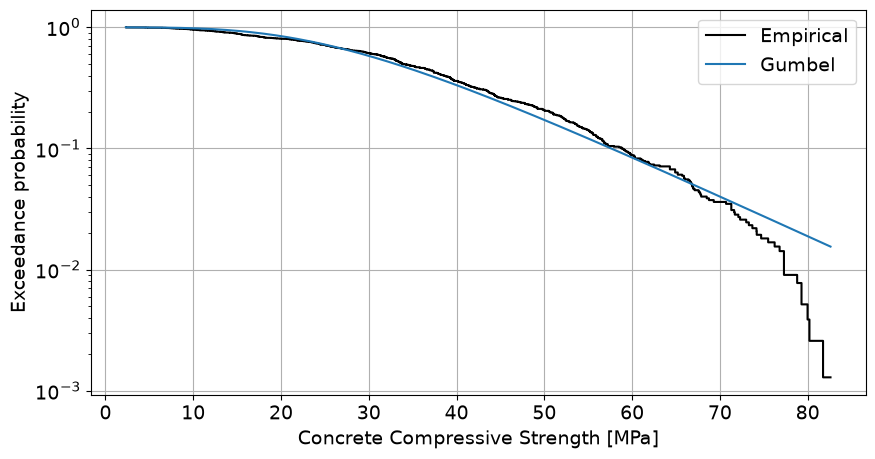

In [125]:
# Visually compare the exceedance probabilities
non_exceedance_probabilities, sorted_values = ecdf(data)
cdf = 1 - gumbel_r.cdf(sorted_values, loc, scale)
exceedance_probabilities = 1 - non_exceedance_probabilities

fig, axes = plt.subplots(1, 1, figsize=(10, 5))
axes.step(sorted_values, exceedance_probabilities, color='k', label='Empirical')
axes.plot(sorted_values, cdf, label = 'Gumbel')
plt.legend()
plt.xlabel('Concrete Compressive Strength [MPa]')
plt.ylabel('Exceedance probability')
axes.grid()
axes.set_yscale('log')

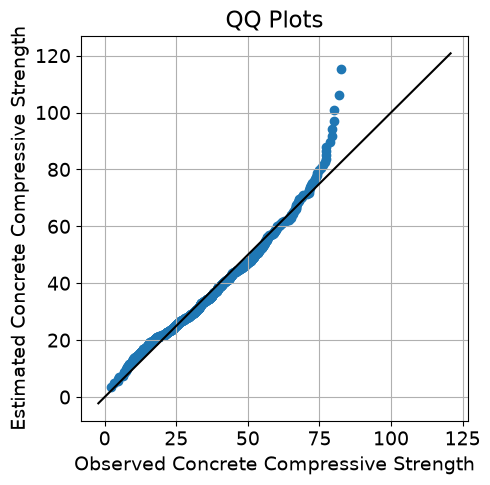

In [132]:
# Visually compare the QQ plots
inverse_cdf = gumbel_r.ppf(non_exceedance_probabilities, loc, scale)

fig, axes = plt.subplots(1, 1, figsize=(5,5))
axes.scatter(sorted_values, inverse_cdf)
plt.xlabel('Observed Concrete Compressive Strength')
plt.ylabel('Estimated Concrete Compressive Strength')
plt.title('QQ Plots')
xlims = axes.get_xlim()
ylims = axes.get_ylim()
lo = np.min([xlims[0], ylims[0]])
hi = np.max([xlims[1], ylims[1]])
axes.plot([lo, hi], [lo, hi], color='k')
axes.grid()

*Your answer here.*

**End of Part 3.** So far, everything you've fitted and assessed has been about a *single* variable at a time. In Part 4, we ask a different kind of question: how do *two* variables relate to each other? We'll answer it using tables built directly from data, connecting to the discrete joint/marginal/conditional probability material from this week's lecture.

## Case: height and shoe size in *this year's* MUDE class

In Parts 1-3, you fitted a continuous parametric distribution to a single variable. Here, we look at **two** continuous variables at once — height and shoe size, from this year's course questionnaire — and ask a new kind of question: not "what distribution fits each one on its own?", but "how are they related?". We'll answer that using the discrete joint / marginal / conditional probability tools from Monday's lecture, applied to height and shoe size after grouping each into a few categories.

**The goal of this part is:**
1. Look at the raw relationship between two continuous variables.
2. Turn each variable into a small number of categories.
3. Build a contingency table, and compute joint, marginal, and conditional probabilities from it.
4. Use those probabilities to informally check whether the two variables look independent.

**A note on the data:** `dataset_class_survey_2026.csv` only includes responses from students who agreed to let us reuse their answers in future years (112 of 127 respondents). No names, emails, or timestamps are included.


In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

findfile('dataset_class_survey_2026.csv')

survey = pd.read_csv('dataset_class_survey_2026.csv')
survey[['height_cm', 'shoe_size']].describe()

,height_cm,shoe_size
count,112.000000,112.000000
mean,178.955357,42.125000
std,10.597797,3.549838
min,150.000000,24.500000
25%,171.000000,40.875000
50%,180.000000,43.000000
75%,186.250000,44.000000
max,206.000000,50.000000


>**Task 4.1:**
>
>Make a scatter plot of `shoe_size` (y-axis) against `height_cm` (x-axis). Do the two variables look related?
>


Text(0.5, 1.0, 'Shoe size vs height')

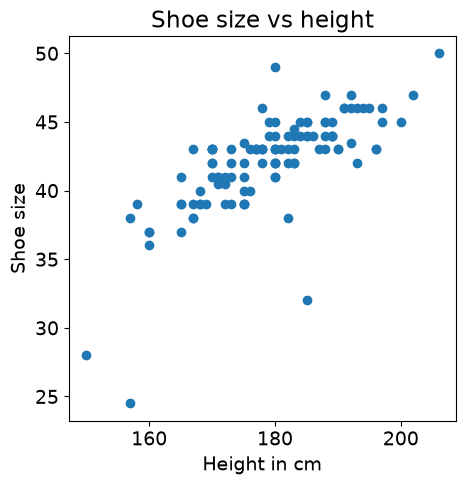

In [156]:
height_cm = survey['height_cm']
shoe_size = survey['shoe_size']

fig, axes = plt.subplots(1, 1, figsize=(5,5))
axes.scatter(height_cm, shoe_size)
plt.xlabel('Height in cm')
plt.ylabel('Shoe size')
plt.title('Shoe size vs height')

>**Task 4.2 — clean the data first:**
>
>The questionnaire asked respondents to report their shoe size using the EU sizing system. Inspect the smallest values of `shoe_size`. A few responses appear inconsistent with the requested scale and may have been entered using a different convention, such as foot length in centimetres.
>
>Identify those observations and decide how to handle them. State your cleaning rule explicitly before continuing.
>


In [167]:
sorted = np.sort(shoe_size)
print(sorted[0:4])

mask = survey['shoe_size'] > 33

height_cm = survey.loc[mask, 'height_cm']
shoe_size = survey.loc[mask, 'shoe_size']

print(np.sort(shoe_size))

### inspect the smallest values of survey['shoe_size'] and clean the dataframe

[36. 37. 37. 37.]
[36.  37.  37.  37.  38.  38.  38.  38.  39.  39.  39.  39.  39.  39.
 39.  39.  39.  39.  39.  39.  40.  40.  40.  40.5 40.5 41.  41.  41.
 41.  41.  41.  41.  41.  41.  42.  42.  42.  42.  42.  42.  42.  42.
 42.  42.  42.  42.  43.  43.  43.  43.  43.  43.  43.  43.  43.  43.
 43.  43.  43.  43.  43.  43.  43.  43.  43.  43.  43.  43.  43.  43.
 43.  43.5 43.5 44.  44.  44.  44.  44.  44.  44.  44.  44.  44.  44.
 44.  44.5 45.  45.  45.  45.  45.  45.  45.  45.  45.  45.  46.  46.
 46.  46.  46.  46.  46.  46.  47.  47.  47.  49.  50. ]


In [201]:
print(np.sort(survey['shoe_size'].values)[:6])
# [24.5 28.  32.  36.  37.  37. ]
# The three values below 35 are implausible shoe sizes for an adult (in the EU shoe size scale, which was requested in the 
# questionnaire) and are treated as data-entry errors / joke answers, not real observations.
survey = survey[survey['shoe_size'] >= 35]

[24.5 28.  32.  36.  37.  37. ]


We want to turn both continuous variables into three categories: **Small**, **Medium**, and **Large**.

For each variable, we divide the range from its minimum to its maximum into **three intervals of equal width**. Then we use `pd.cut` to assign each observation to one of the three categories. Finally, we store the resulting categories as new columns `height_cat` and `shoe_cat` in `survey`.

In [202]:
# Our labels for both categories
labels = ['Small', 'Medium', 'Large']

# Three bins have four edges: | 1 | 2 | 3 |
height_edges = np.linspace(
    survey['height_cm'].min(),
    survey['height_cm'].max(),
    4
)

# Three bins have four edges: | 1 | 2 | 3 |
shoe_edges = np.linspace(
    survey['shoe_size'].min(),
    survey['shoe_size'].max(),
    4
)

# Divide height into the bin categories
survey['height_cat'] = pd.cut(
    survey['height_cm'],
    bins=height_edges,
    labels=labels,
    include_lowest=True
)

# Divide shoe size into the bin categories
survey['shoe_cat'] = pd.cut(
    survey['shoe_size'],
    bins=shoe_edges,
    labels=labels,
    include_lowest=True
)

print('Height edges:', np.round(height_edges, 1))
print('Shoe-size edges:', np.round(shoe_edges, 1))

survey[['height_cm', 'height_cat', 'shoe_size', 'shoe_cat']].head()

Height edges: [157.  173.3 189.7 206. ]
Shoe-size edges: [36.  40.7 45.3 50. ]


,height_cm,height_cat,shoe_size,shoe_cat
0,168.0,Small,39.0,Small
1,177.0,Medium,43.0,Medium
2,175.0,Medium,39.0,Small
3,189.0,Medium,44.0,Medium
4,183.0,Medium,43.0,Medium


>**Task 4.3:**
>Before building the full contingency table, calculate one entry manually.
>
>How many students have both:
>
>- `height_cat == 'Small'`, and
>- `shoe_cat == 'Small'`?
>
>Use Boolean indexing to count the observations satisfying both conditions. tore the result as `n_small_small`.
>


In [210]:
n_small_small = ((survey['height_cat'] == 'Small') & (survey['shoe_cat'] == 'Small')).sum()
print(n_small_small)

19


>**Task 4.4:**
>
>You just counted one combination of categories manually. Pandas can repeat this operation for every combination at once using [`.crosstab`](https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html), which creates a full contingency table for you! The first argument defines the row categories and the second defines the column categories.
>
>We use the categorized columns in survey to construct the full contingency table, with height categories as rows and shoe-size categories as columns.
>
>Verify that the Small / Small entry agrees with your result from Task 4.4.
>
>Then convert the counts into **joint probabilities** by dividing the entire table by the total number of observations:
>
>$$P(A,B)=\frac{\mathrm{count}(A,B)}{n}.$$
>
>


In [211]:
# Count every combination of height and shoe-size category
counts = pd.crosstab(
    survey['height_cat'],
    survey['shoe_cat']
)

print("Raw data table:")
print(counts)

# Check one entry against the count you calculated manually in Task 4.4
assert counts.loc['Small', 'Small'] == n_small_small

# Convert counts to joint probabilities
joint = counts / counts.values.sum()

print("Joint probabilities:")
joint.round(3)

Raw data table:
shoe_cat    Small  Medium  Large
height_cat                      
Small          19      15      0
Medium          6      48      3
Large           0       8     10
Joint probabilities:


shoe_cat,Small,Medium,Large
height_cat,,,
Small,0.174,0.138,0.000
Medium,0.055,0.440,0.028
Large,0.000,0.073,0.092


>**Task 4.5:**
>
>The joint probability table describes height and shoe size **jointly**. Now compute the two **marginal probability distributions**:
>
>- the probability distribution of height category, regardless of shoe size;
>- the probability distribution of shoe-size category, regardless of height.
>
>Compute each marginal distribution by summing the appropriate entries of the joint probability table. Check that each marginal distribution sums to 1.
>
>Finally, think back to how we created the categories. We used intervals of **equal width**. If instead we had divided each variable into three groups using its empirical quantiles, approximately what would you expect the three marginal probabilities to be?
>
>


In [212]:
#Height
Small_H = joint.sum(axis=1)['Small']
Medium_H = joint.sum(axis=1)['Medium']
Large_H = joint.sum(axis=1)['Large']

Small_S = joint.sum(axis=0)['Small']
Medium_S = joint.sum(axis=0)['Medium']
Large_S = joint.sum(axis=0)['Large']

marginal_height = Small_H + Medium_H + Large_H
marginal_shoe = Small_S + Medium_S + Large_S
print('height_cat')
print(f'Small    {Small_H:.4f}')
print(f'Medium   {Medium_H:.4f}')
print(f'Large    {Large_H:.4f}')
print('shoe_cat')
print(f'Small    {Small_S:.4f}')
print(f'Medium   {Medium_S:.4f}')
print(f'Large    {Large_S:.4f}')
print(f'The sum of the marginal distribution of the height is {marginal_height}')
print(f'The sum of the marginal distribution of the shoe size is {marginal_shoe}')

height_cat
Small    0.3119
Medium   0.5229
Large    0.1651
shoe_cat
Small    0.2294
Medium   0.6514
Large    0.1193
The sum of the marginal distribution of the height is 1.0
The sum of the marginal distribution of the shoe size is 1.0


In [214]:
marginal_height = joint.sum(axis=1)
marginal_shoe = joint.sum(axis=0)
print(marginal_height)
print(marginal_shoe)

height_cat
Small     0.311927
Medium    0.522936
Large     0.165138
dtype: float64
shoe_cat
Small     0.229358
Medium    0.651376
Large     0.119266
dtype: float64


The three probabilities should be 1/3 if they would be divided equally. But they are not close to 1/3, so there are not equal-sized groups. The largest group is the medium, because most people fall in that group.

>**Task 4.6:**
>
>So far, the marginal distribution of shoe size described the whole class.
>
>Now consider only students in the **Small height** category. Among these students, what is the probability distribution of shoe-size category?
>
>Then repeat the calculation for students in the **Large height** category.
>
>Use the joint and marginal probabilities from the previous tasks. Recall that conditioning means restricting the population we are considering and renormalizing the corresponding probabilities. 
>


In [215]:
shoe_given_small_height = joint.loc['Small'] / marginal_height.loc['Small']
shoe_given_large_height = joint.loc['Large'] / marginal_height.loc['Large']

print('Shoe size | Small height')
print(shoe_given_small_height.round(3))

print('\nShoe size | Large height')
print(shoe_given_large_height.round(3))

Shoe size | Small height
shoe_cat
Small     0.559
Medium    0.441
Large     0.000
Name: Small, dtype: float64

Shoe size | Large height
shoe_cat
Small     0.000
Medium    0.444
Large     0.556
Name: Large, dtype: float64


>**Task 4.7:**
>
>Compare the **marginal distribution of shoe size** from Task 4.5 with the two **conditional distributions of shoe size** from Task 4.6.
>
>If height category and shoe-size category were independent, what relationship would you expect between the marginal and conditional distributions?
>
>Does that appear to be the case for these data? Support your conclusion with specific probabilities from your results.
>
>


It is shown that for the conditional distributions of shoe size the most people fall in the large group, if the condition was also that the height was large and vice versa. This makes sense, but this difference from the marginal distribution where the most people fall in the middle group. If they were independent I think that the relationship between the marginal and conditional distribution is that they will be the same. For example the probability that you fall in the small group shoe size with a marginal distribution is 0.23, but if the condition is that you have a small height then the probability for a small shoe size is 0.559. 

>**Task 4.8 (optional / if you have time):**
>
>Try the same recipe (scatter &rarr; clean &rarr; bin into equal-width categories &rarr; contingency table &rarr; conditional probabilities) on another pair of variables in `dataset_class_survey_2026.csv`:
>- two more continuous variables, e.g. `rent_eur` vs. `room_size_m2` (also needs cleaning &mdash; check for implausible values first!)
>- or two categorical variables, e.g. `hair_color` vs. `eye_color` (the original lecture example, for comparison), or `cats_or_dogs` vs. `degree` (equal-width binning doesn't apply to these &mdash; they're already categories)
>Which pairs show a strong dependence, and which look closer to independent?


In [ ]:
### YOUR CODE HERE

**End of Part 4.**

You've now practiced the discrete counterpart of the fitting workflow from Parts 1-3: instead of fitting a continuous parametric distribution to one variable, you grouped **two** continuous variables into equal-width categories and built an *empirical* joint distribution directly from the counts, then used conditional probabilities to reason about dependence. On Friday, you'll apply the same recipe &mdash; scatter plot, then bin into equal-width Low/Medium/High categories, then contingency table &mdash; to the two continuous variables in the group assignment.
> By Max Ramgraber, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2026/credits.html).